# Train + Validate + Calibrate

Uses the modular pipeline (DataModule → Model → Trainer). Edit overrides to swap models/augs/hparams/W&B.


In [1]:
import sys
from pathlib import Path

# Prefer local src/ over any installed package
sys.path.insert(0, str((Path("..").resolve() / "src")))

In [2]:
# Choose device manually ("cpu" or "cuda"); set to None to auto-detect
DEVICE_OVERRIDE = None  # e.g., "cpu" to force CPU, "cuda" to force GPU if available

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Plot theming
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.dpi': 300, 'savefig.dpi': 300, 'axes.titlesize': 12, 'axes.labelsize': 11, 'legend.fontsize': 10})

PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

def save_fig(fig, name: str, prefix: str = "train"):
    path = PLOTS_DIR / f"{prefix}_{name}.pdf"
    fig.savefig(path, bbox_inches='tight', format='pdf')
    print(f"Saved figure to {path}")
    return path

In [4]:
from config import TrainConfig, build_config_from_dict
from training import Trainer

overrides = {
    "data_root": str(Path("../data")),
    "checkpoints_dir": str(Path("../artifacts/checkpoints")),
    "epochs": 5,  # bump for full runs
    "wandb_mode": "disabled",  # set to 'online' to log to W&B
    "tensorboard": False,  # set True to log TensorBoard summaries to tensorboard_dir
    "progress_bar": True,
    # "model_name": "efficientnet_b0",
    # "horizontal_flip": 0.5,
    # "max_rotation": 15,
}

cfg = build_config_from_dict(overrides)
if DEVICE_OVERRIDE:
    cfg.device_override = DEVICE_OVERRIDE  # Trainer will respect this attr if set
cfg

TrainConfig(data_root='../data', batch_size=64, num_workers=4, image_size=256, mean=(0.43, 0.411, 0.374), std=(0.218, 0.207, 0.203), horizontal_flip=0.5, max_rotation=15.0, color_jitter=(0.15, 0.15, 0.15, 0.05), balance_strategy='weighted_sampler', model_name='resnet18', pretrained=True, num_classes=2, dropout=0.1, in_channels=3, freeze_backbone=False, optimizer='adamw', lr=0.0003, weight_decay=0.0001, betas=(0.9, 0.999), momentum=0.9, epochs=5, label_smoothing=0.05, amp=True, grad_clip_norm=1.0, early_stopping=5, checkpoint_metric='macro_f1', progress_bar=True, threshold=0.5, reliability_bins=15, apply_temperature=True, checkpoints_dir='../artifacts/checkpoints', wandb_mode='disabled', wandb_project='hurricane-damage', wandb_entity=None, wandb_run_name=None, wandb_tags=[], tensorboard=False, tensorboard_dir='artifacts/tensorboard', seed=42)

In [5]:
trainer = Trainer(cfg)
train_summary = trainer.fit()
test_metrics = trainer.test()
train_summary, test_metrics

Epoch 1/5:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-05 23:05:26,796 | INFO | Epoch 000 | train_loss=0.1957 | val_loss=0.8419 | val_f1=0.612


Epoch 2/5:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-05 23:05:45,544 | INFO | Epoch 001 | train_loss=0.1499 | val_loss=0.2043 | val_f1=0.953


Epoch 3/5:   0%|          | 0/296 [00:00<?, ?it/s]

...

Epoch 4/5:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-05 23:06:22,468 | INFO | Epoch 003 | train_loss=0.1283 | val_loss=0.2644 | val_f1=0.927


Epoch 5/5:   0%|          | 0/296 [00:00<?, ?it/s]

2025-12-05 23:06:41,037 | INFO | Epoch 004 | train_loss=0.1250 | val_loss=0.2054 | val_f1=0.955


({'history': [{'epoch': 0,
    'train_loss': 0.19573039256942434,
    'val_loss': 0.8419042229652405,
    'val/accuracy': 0.6575,
    'val/macro_precision': 0.7967359050445104,
    'val/macro_recall': 0.6575,
    'val/macro_f1': 0.6119832048204714,
    'val/brier': 0.25911877557386764,
    'val/ece': 0.23028412061929704,
    'lr': 0.0002714480406590546},
   {'epoch': 1,
    'train_loss': 0.1499336863540717,
    'val_loss': 0.20427939295768738,
    'val/accuracy': 0.9535,
    'val/macro_precision': 0.9536310993877231,
    'val/macro_recall': 0.9535,
    'val/macro_f1': 0.9534966401322496,
    'val/brier': 0.03313985616759273,
    'val/ece': 0.02205650985240939,
    'lr': 0.00019669804065905458},
   {'epoch': 2,
    'train_loss': 0.13587126853196202,
    'val_loss': 0.24034333229064941,
    'val/accuracy': 0.94,
    'val/macro_precision': 0.9462130707977885,
    'val/macro_recall': 0.94,
    'val/macro_f1': 0.9397904104186674,
    'val/brier': 0.044722590303932386,
    'val/ece': 0.01720

,epoch,train_loss,val_loss,val/accuracy,val/macro_precision,val/macro_recall,val/macro_f1,val/brier,val/ece,lr
0,0,0.195730,0.841904,0.6575,0.796736,0.6575,0.611983,0.259119,0.230284,0.000271
1,1,0.149934,0.204279,0.9535,0.953631,0.9535,0.953497,0.033140,0.022057,0.000197
2,2,0.135871,0.240343,0.9400,0.946213,0.9400,0.939790,0.044723,0.017207,0.000104
3,3,0.128292,0.264415,0.9270,0.936300,0.9270,0.926609,0.055743,0.025514,0.000030
4,4,0.125026,0.205353,0.9550,0.958551,0.9550,0.954913,0.033993,0.030776,0.000001


Saved figure to ../plots/train_loss_curves.pdf


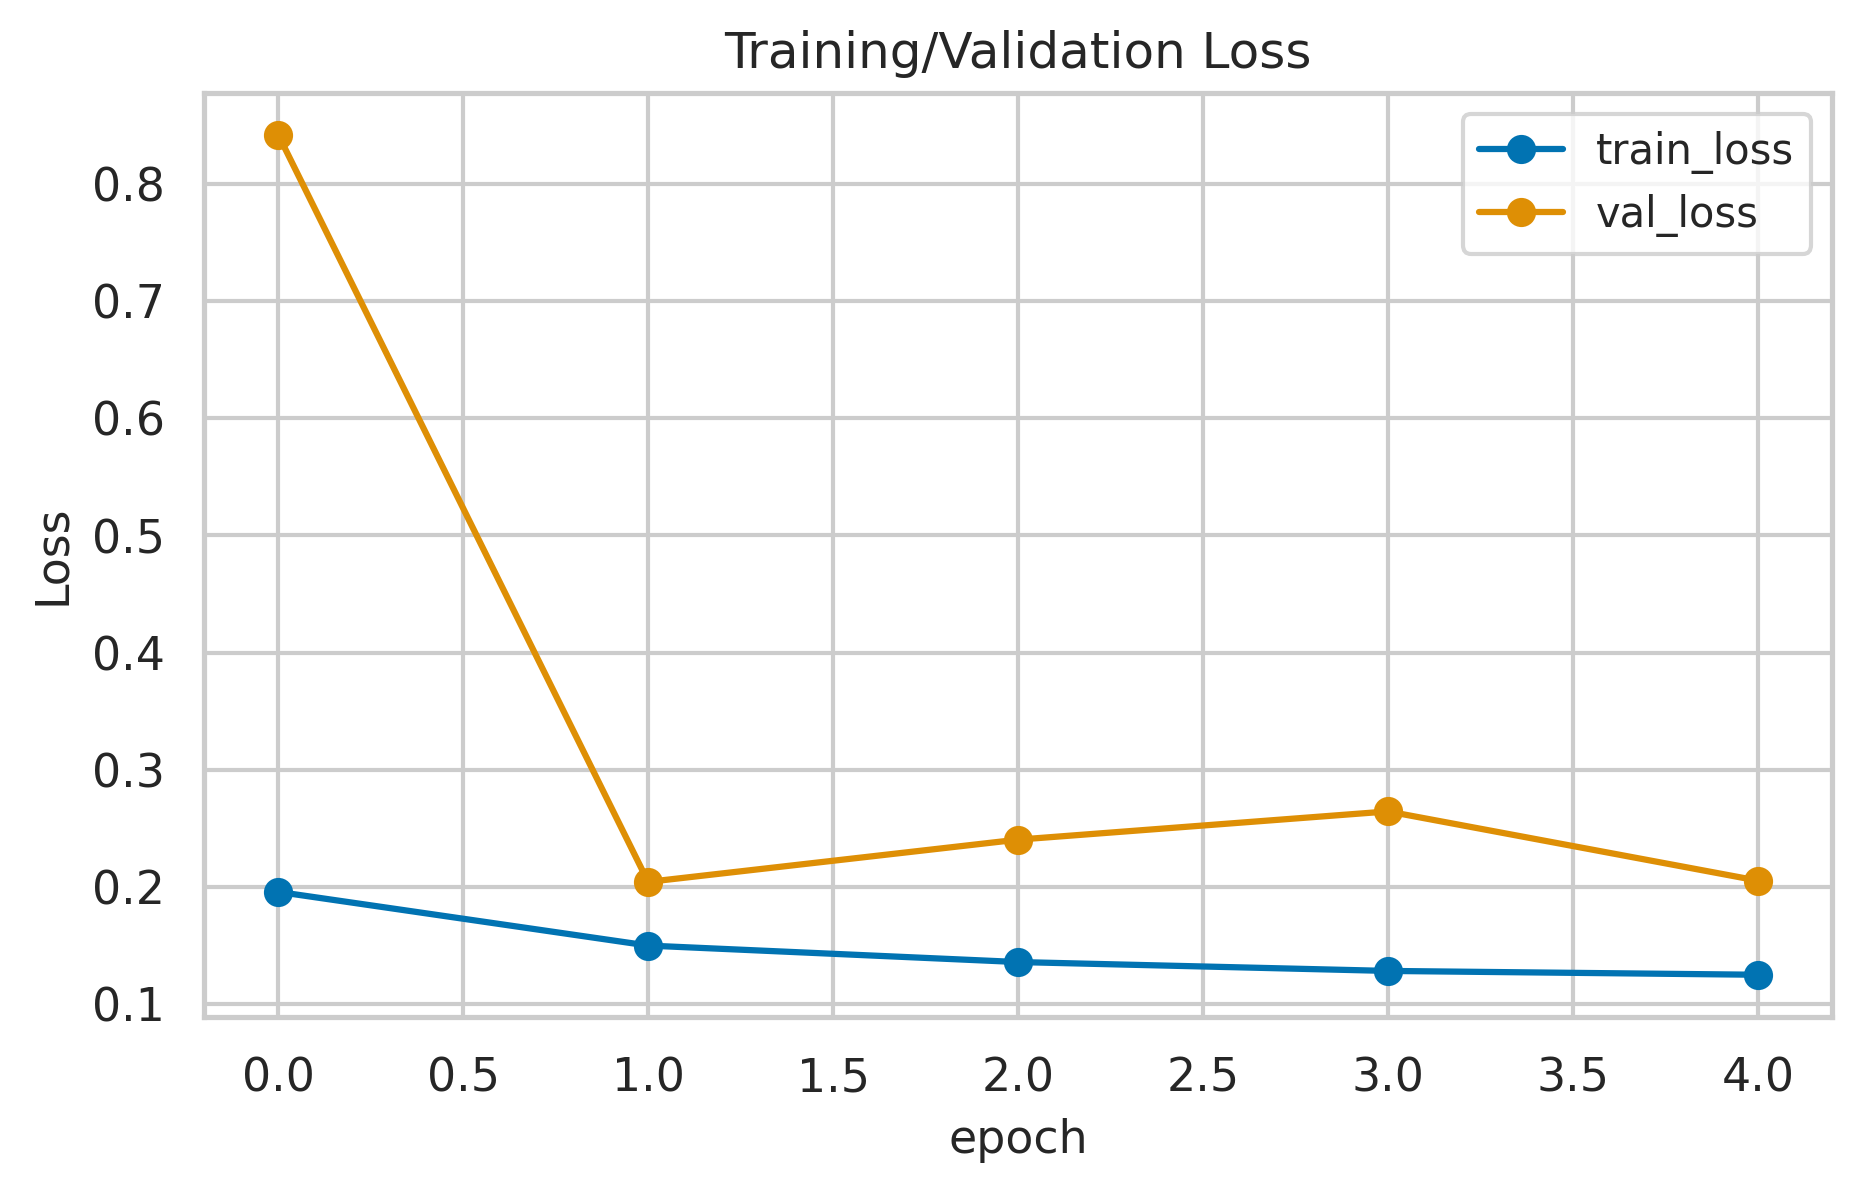

Saved figure to ../plots/train_val_metrics.pdf


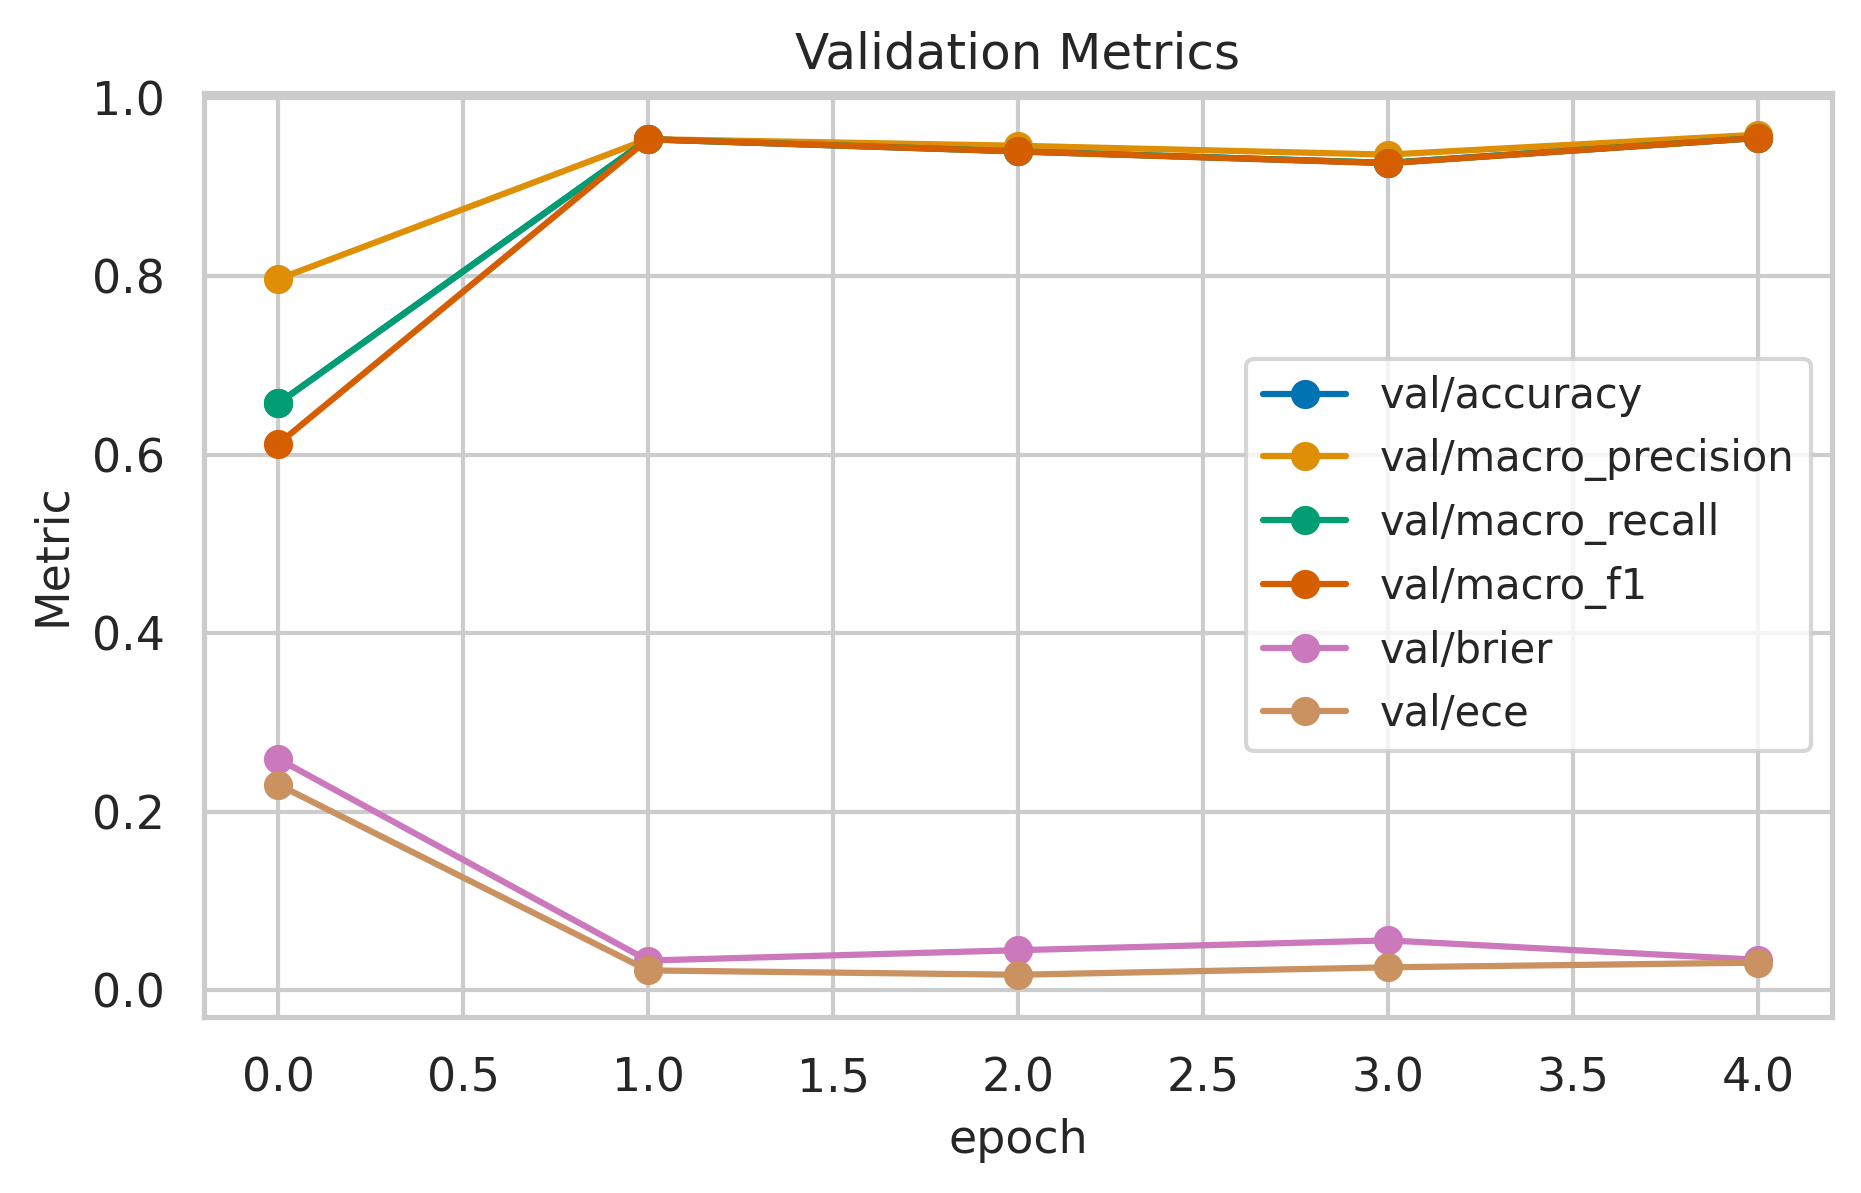

Saved figure to ../plots/train_confusion.pdf


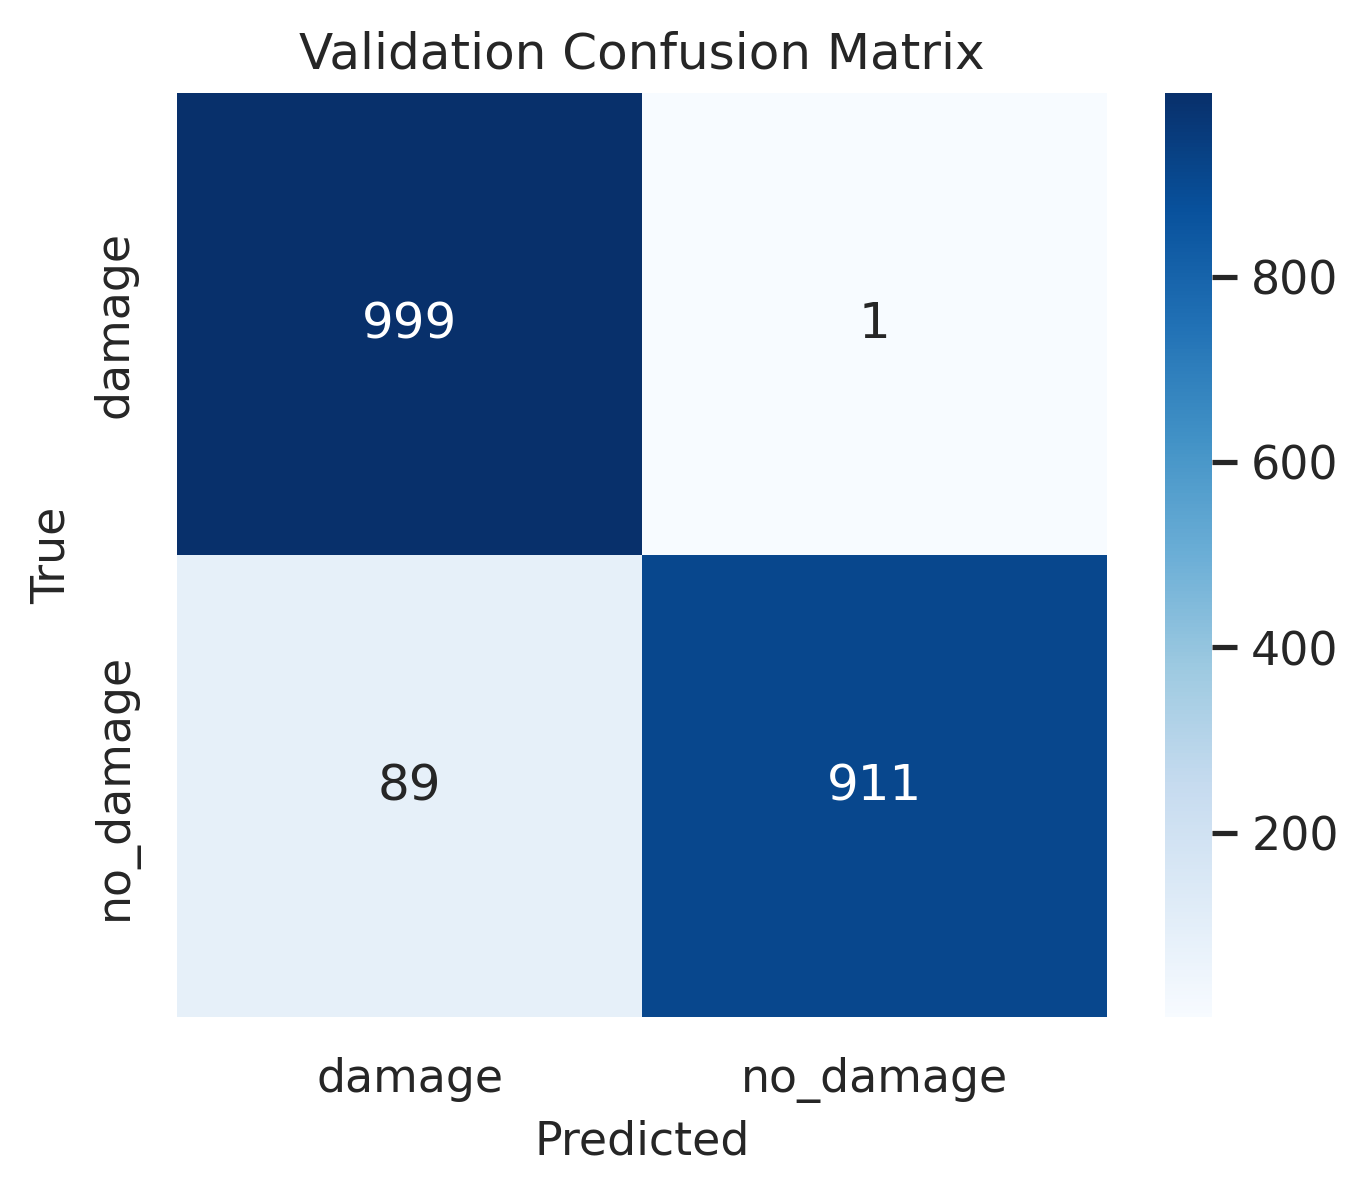

Saved figure to ../plots/train_score_hist.pdf


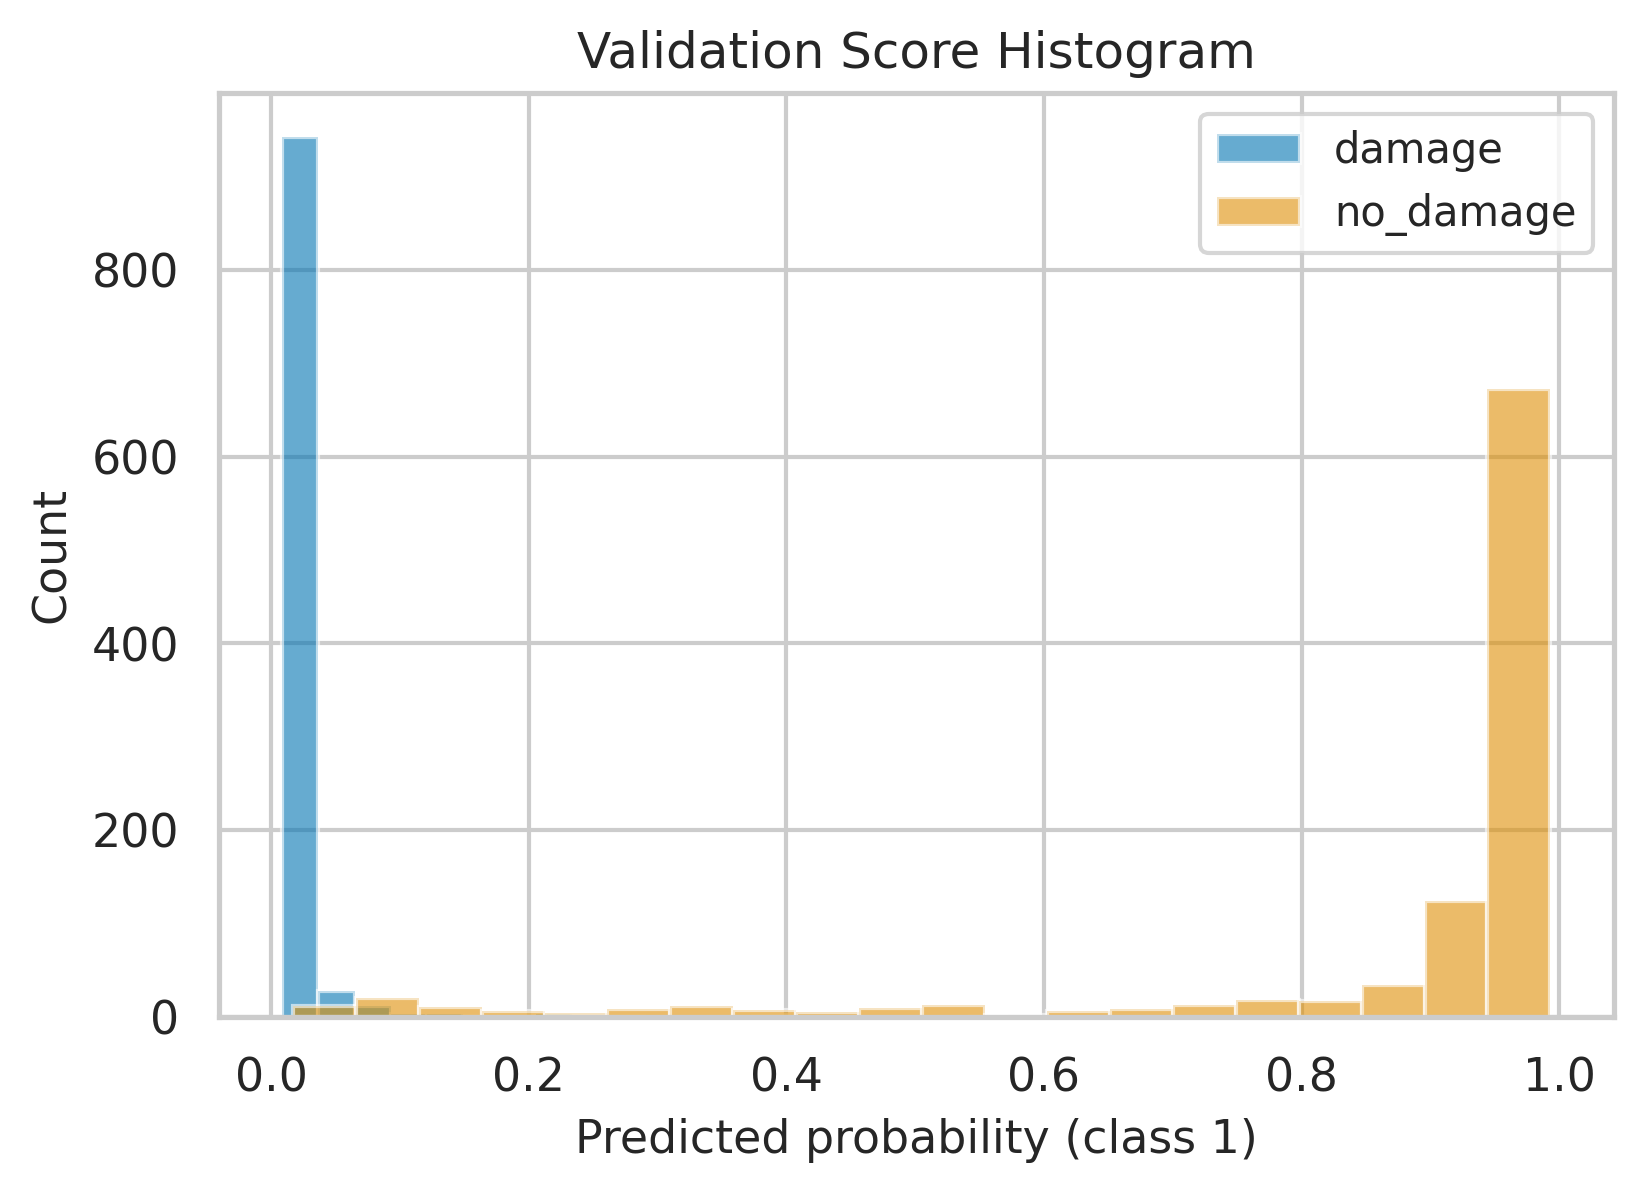

Saved figure to ../plots/train_reliability.pdf


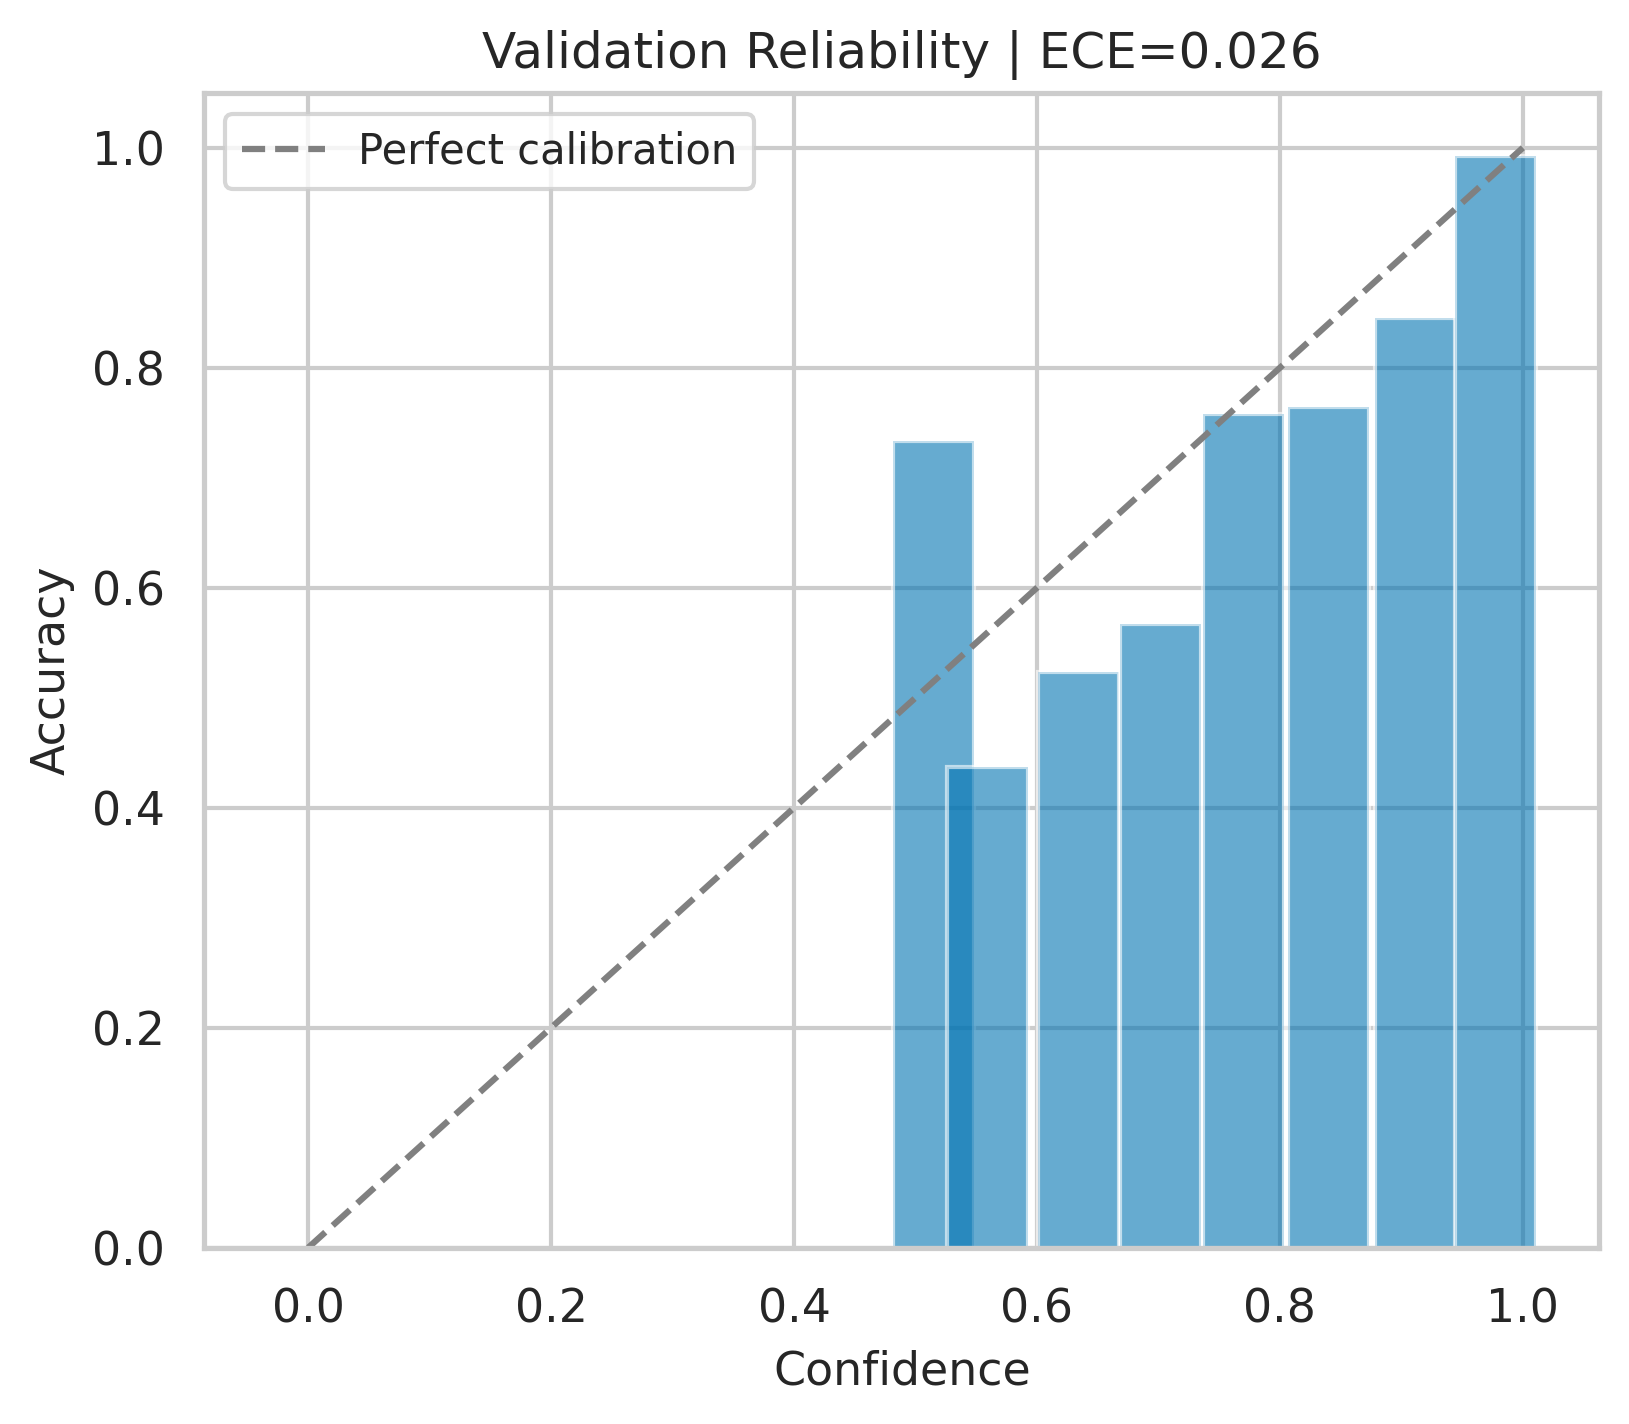

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from validation import evaluate, reliability_bins

history_df = pd.DataFrame(train_summary["history"])
display(history_df)

# Loss curves
fig, ax = plt.subplots(figsize=(7, 4))
history_df.plot(x="epoch", y=["train_loss", "val_loss"], marker="o", ax=ax)
ax.set_ylabel("Loss")
ax.set_title("Training/Validation Loss")
save_fig(fig, "loss_curves")
plt.show()

# Validation metrics over epochs
metric_cols = [col for col in history_df.columns if col.startswith("val/") and col not in ("val/loss",)]
if metric_cols:
    fig, ax = plt.subplots(figsize=(7, 4))
    history_df.plot(x="epoch", y=metric_cols, marker="o", ax=ax)
    ax.set_ylabel("Metric")
    ax.set_title("Validation Metrics")
    save_fig(fig, "val_metrics")
    plt.show()

# Evaluate on validation for detailed plots
val_metrics, val_outputs = evaluate(
    trainer.model,
    trainer.val_loader,
    trainer.device,
    trainer.cfg,
    temperature=getattr(trainer, "temperature", None),
)

val_probs = val_outputs["probs"]
val_labels = val_outputs["labels"].cpu().numpy()
val_preds = val_probs.argmax(axis=1)
class_names = trainer.datamodule.train_dataset.classes

# Confusion matrix
cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Validation Confusion Matrix")
save_fig(fig, "confusion")
plt.show()

# Score histogram for positive class
pos_scores = val_probs[:, 1] if val_probs.shape[1] > 1 else val_probs[:, 0]
fig, ax = plt.subplots(figsize=(6, 4))
for label_val, label_name in enumerate(class_names):
    ax.hist(pos_scores[val_labels == label_val], bins=20, alpha=0.6, label=label_name)
ax.set_xlabel("Predicted probability (class 1)")
ax.set_ylabel("Count")
ax.set_title("Validation Score Histogram")
ax.legend()
save_fig(fig, "score_hist")
plt.show()

# Reliability diagram
bin_conf, bin_acc, bin_count = reliability_bins(
    val_probs, val_labels, n_bins=trainer.cfg.reliability_bins
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.bar(bin_conf, bin_acc, width=1.0 / trainer.cfg.reliability_bins, alpha=0.6, align="center")
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title(f"Validation Reliability | ECE={val_metrics['ece']:.3f}")
ax.legend()
save_fig(fig, "reliability")
plt.show()